In [56]:
# import libaries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings("ignore")

In [58]:
# Read Dataset
df = pd.read_csv('UberDataset.csv')
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1151,12/31/2016 13:24,12/31/2016 13:42,Business,Kar?chi,Unknown Location,3.9,Temporary Site
1152,12/31/2016 15:03,12/31/2016 15:38,Business,Unknown Location,Unknown Location,16.2,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016 22:08,12/31/2016 23:51,Business,Gampaha,Ilukwatta,48.2,Temporary Site


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1156 entries, 0 to 1155
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   START_DATE  1156 non-null   object 
 1   END_DATE    1155 non-null   object 
 2   CATEGORY    1155 non-null   object 
 3   START       1155 non-null   object 
 4   STOP        1155 non-null   object 
 5   MILES       1156 non-null   float64
 6   PURPOSE     653 non-null    object 
dtypes: float64(1), object(6)
memory usage: 63.3+ KB


In [60]:
df.shape

(1156, 7)

# Data Preprocessing 

In [88]:
df['PURPOSE'].fillna("NOT", inplace = True)

In [89]:
df.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,DAY,MONTH
0,2016-01-01 21:11:00,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,Fri,Jan
1,2016-01-02 01:25:00,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NOT,Sat,Jan
2,2016-01-02 20:25:00,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,Sat,Jan
3,2016-01-05 17:31:00,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting,Tues,Jan
4,2016-01-06 14:42:00,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,Wed,Jan


In [90]:
df['START_DATE'] = pd.to_datetime(df['START_DATE'], errors = 'coerce')

df['END_DATE'] = pd.to_datetime(df['END_DATE'], errors = 'coerce')

In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1156 entries, 0 to 1155
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   START_DATE  421 non-null    datetime64[ns]
 1   END_DATE    420 non-null    datetime64[ns]
 2   CATEGORY    1155 non-null   object        
 3   START       1155 non-null   object        
 4   STOP        1155 non-null   object        
 5   MILES       1156 non-null   float64       
 6   PURPOSE     1156 non-null   object        
 7   DAY         421 non-null    object        
 8   MONTH       421 non-null    object        
dtypes: datetime64[ns](2), float64(1), object(6)
memory usage: 81.4+ KB


In [92]:
from datetime import datetime

df['date'] = pd.DatetimeIndex(df['START_DATE']).date
df['time'] = pd.DatetimeIndex(df['START_DATE']).hour

In [93]:
df.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,DAY,MONTH,date,time
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,Fri,Jan,2016-01-01,21.0
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,NOT,Sat,Jan,2016-01-02,1.0
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,Sat,Jan,2016-01-02,20.0
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,Tues,Jan,2016-01-05,17.0
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,Wed,Jan,2016-01-06,14.0


In [94]:
df['day-night'] = pd.cut(x=df['time'],bins= [0,10,15,19,24],labels = ['Morning', 'Afternoon', 'Evening', 'Night'])

In [95]:
df.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,DAY,MONTH,date,time,day-night
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,Fri,Jan,2016-01-01,21.0,Night
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,NOT,Sat,Jan,2016-01-02,1.0,Morning
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,Sat,Jan,2016-01-02,20.0,Night
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,Tues,Jan,2016-01-05,17.0,Evening
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,Wed,Jan,2016-01-06,14.0,Afternoon


In [96]:
df.dropna(inplace = True)

In [97]:
df.shape

(413, 12)

# DATA VISUALZATION

<Axes: xlabel='count', ylabel='PURPOSE'>

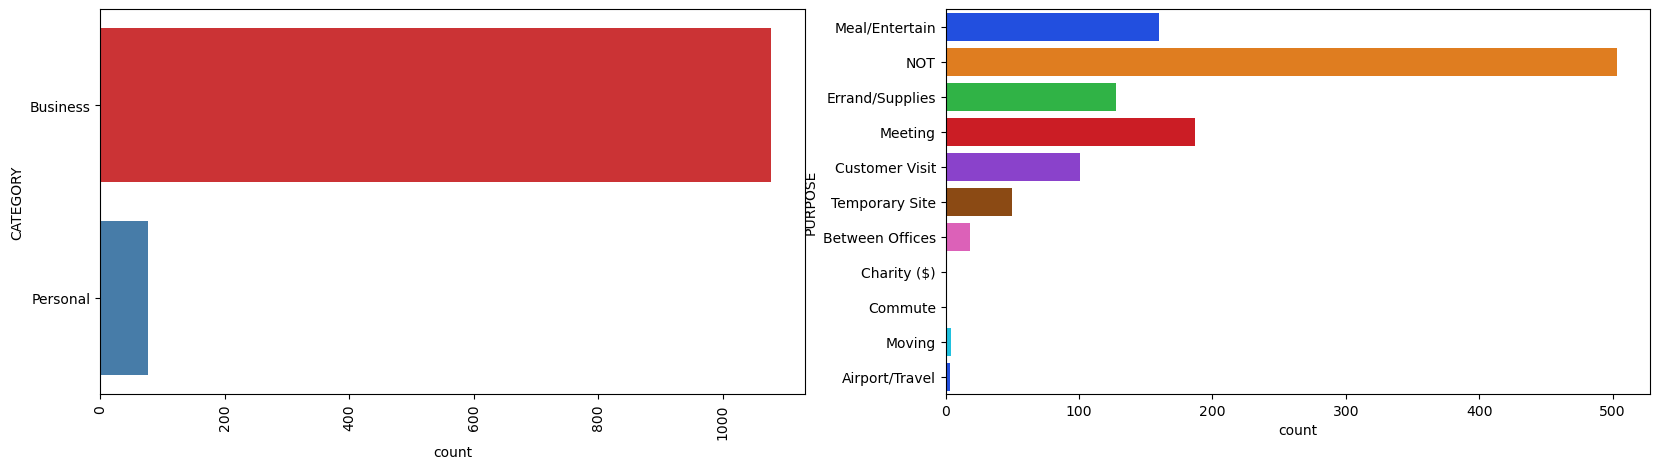

In [72]:
plt.figure(figsize = (20, 5))

plt.subplot(1,2,1)
sns.countplot(df['CATEGORY'], palette='Set1')
plt.xticks(rotation = 90)

plt.subplot(1,2,2)
sns.countplot(df['PURPOSE'], palette='bright')

### Conclusion - 
### 1. Bussiness category do people book the most uber rides.

### 2. For  Meeting purpose do people book Uber rides the most

<Axes: xlabel='count', ylabel='day-night'>

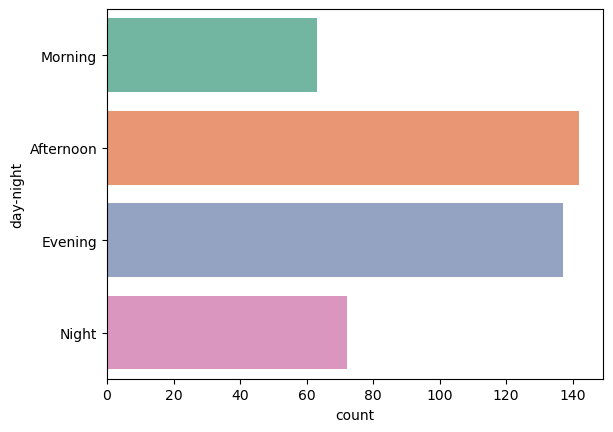

In [73]:
sns.countplot(df['day-night'], palette='Set2')

### conclusion - At Afternoon time do people book cabs the most from Uber.

In [98]:
df['MONTH'] = pd.DatetimeIndex(df['START_DATE']).month

month_label = {1.0 : 'Jan', 2.0 : 'Feb', 3.0 : 'Mar', 4.0 : 'April',
               5.0 : 'May', 6.0 : 'June', 7.0 : 'July', 8.0 : 'Aug', 
               9.0 : 'Sep', 10.0 : 'Oct', 11.0 : 'Nov', 12.0 : 'Dec'}

df['MONTH'] = df.MONTH.map(month_label)

mon = df.MONTH.value_counts(sort=False)

In [99]:
df.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,DAY,MONTH,date,time,day-night
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,Fri,Jan,2016-01-01,21.0,Night
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,NOT,Sat,Jan,2016-01-02,1.0,Morning
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,Sat,Jan,2016-01-02,20.0,Night
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,Tues,Jan,2016-01-05,17.0,Evening
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,Wed,Jan,2016-01-06,14.0,Afternoon


[Text(0.5, 0, 'MONTHS'), Text(0, 0.5, 'VALUE COUNT')]

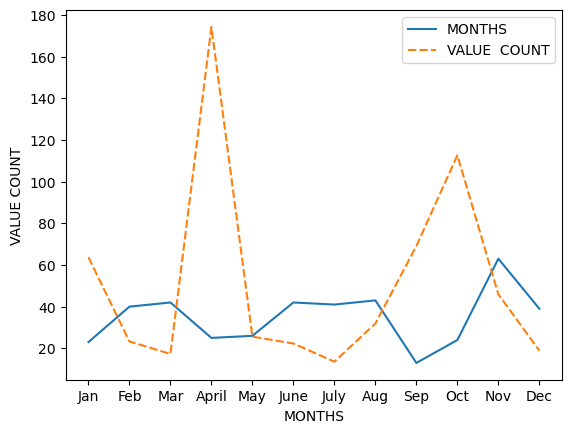

In [76]:
df = pd.DataFrame({
    "MONTHS" : mon.values,
    "VALUE  COUNT" : df.groupby('MONTH', sort=False)['MILES'].max()
})

p = sns.lineplot(data = df)
p.set(xlabel="MONTHS", ylabel="VALUE COUNT")

## conclusion - Jan, Nov, Dec months do people book Uber rides less frequently. 

In [100]:
df['DAY'] = df.START_DATE.dt.weekday

day_label = {
    0: 'Mon', 1: 'Tues', 2: 'Wed',
    3: 'Thur', 4: 'Fri', 5: 'Sat', 6: 'Sun'
}

df['DAY'] = df['DAY'].map(day_label)

In [101]:
df.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,DAY,MONTH,date,time,day-night
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,Fri,Jan,2016-01-01,21.0,Night
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,NOT,Sat,Jan,2016-01-02,1.0,Morning
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,Sat,Jan,2016-01-02,20.0,Night
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,Tues,Jan,2016-01-05,17.0,Evening
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,Wed,Jan,2016-01-06,14.0,Afternoon


In [102]:
df['START_DATE'] = pd.to_datetime(df['START_DATE'], errors='coerce')

df['DAY'] = df.START_DATE.dt.weekday

day_label = {
    0: 'Mon', 1: 'Tues', 2: 'Wed',
    3: 'Thur', 4: 'Fri', 5: 'Sat', 6: 'Sun'
}

df['DAY'] = df['DAY'].map(day_label)

In [103]:
df.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,DAY,MONTH,date,time,day-night
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,Fri,Jan,2016-01-01,21.0,Night
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,NOT,Sat,Jan,2016-01-02,1.0,Morning
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,Sat,Jan,2016-01-02,20.0,Night
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,Tues,Jan,2016-01-05,17.0,Evening
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,Wed,Jan,2016-01-06,14.0,Afternoon


Text(0, 0.5, 'COUNT')

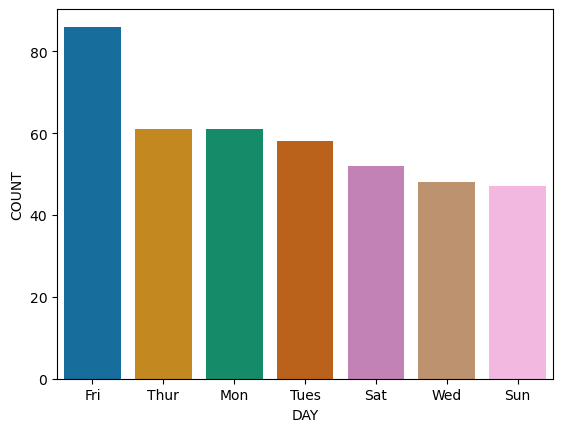

In [110]:
day_label = df.DAY.value_counts()

sns.barplot(x=day_label.index, y=day_label, palette='colorblind')
plt.xlabel('DAY')
plt.ylabel('COUNT')

## Conclusion - From the above visualization, it is observed that Friday has the highest number of Uber bookings, indicating increased demand towards the end of the workweek.

In [111]:
df.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,DAY,MONTH,date,time,day-night
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,Fri,Jan,2016-01-01,21.0,Night
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,NOT,Sat,Jan,2016-01-02,1.0,Morning
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,Sat,Jan,2016-01-02,20.0,Night
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,Tues,Jan,2016-01-05,17.0,Evening
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,Wed,Jan,2016-01-06,14.0,Afternoon


<Axes: ylabel='MILES'>

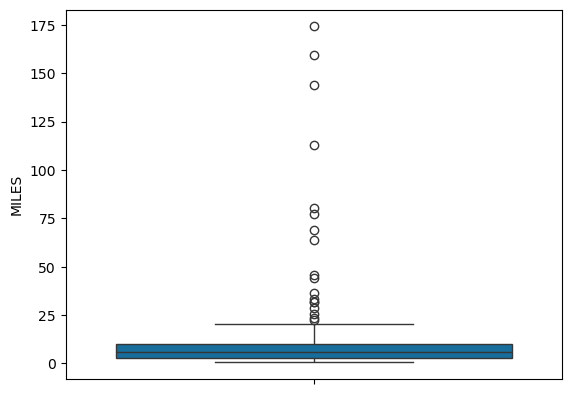

In [113]:
sns.boxplot(df['MILES'])

<Axes: ylabel='MILES'>

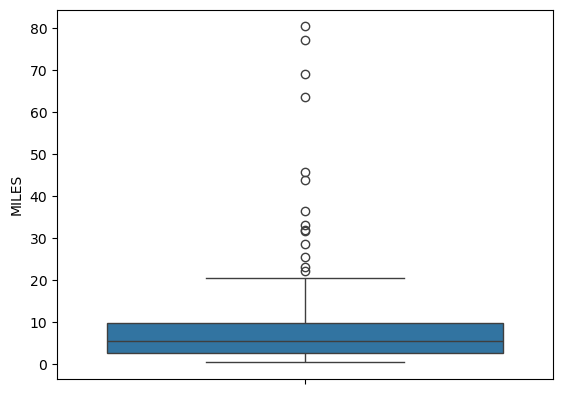

In [114]:
sns.boxplot(df[df['MILES']<100]['MILES'])

<Axes: xlabel='MILES', ylabel='Density'>

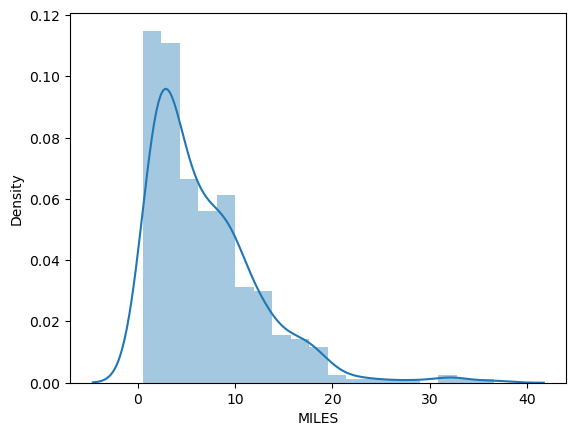

In [118]:
sns.distplot(df[df['MILES']<40]['MILES'])

## Conclusion - from above the visualization 0-20 Miles do people usually book a cap for through Uber.

In [ ]:
-------------------------------------------------------------------- ~ END ~ --------------------------------------------------------------------------